In [1]:
import pandas as pd
import sys

sys.path.append('..')

from src.vectorize import vectorization
from src.model import train, evaluation

df = pd.read_csv("../data/english_comments.csv")

df.head(3)

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers dont even have cont...,negative
2,i will forever acknowledge this channel with t...,positive


In [2]:
# =======================================================================================================
# VECTORIZACIÓN
# =======================================================================================================

X_train, X_test, y_train, y_test = vectorization(df['Comment'], df['Sentiment'])

print("----- Ejemplo ", "-" * 50)
print("-> Comentario como Texto: ", df['Comment'][0])
print("-> Comentario Vectorizado: ", X_train[0].toarray())


Total comentarios para entrenamiento: 12452 (80.0% del total)
66.0% positives
20.0% neutros
14.000000000000002% negativos

Total comentarios para evaluación: 3114 (20.0% del total)
66.0% positives
20.0% neutros
14.000000000000002% negativos

----- Ejemplo  --------------------------------------------------
-> Comentario como Texto:  lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use it even if they wanted to as each successive iphone incorporated the technology and older iphones were replaced the number of people who could use the technology increased
-> Comentario Vectorizado:  [[0. 0. 0. ... 0. 0. 0.]]


----- Modelo MultinomialNB  -------------------------------------------------- 

              precision    recall  f1-score   support

    Positivo       0.57      0.49      0.52       440
      Neutro       0.54      0.48      0.51       625
    Negativo       0.84      0.90      0.87      2049

    accuracy                           0.75      3114
   macro avg       0.65      0.62      0.63      3114
weighted avg       0.74      0.75      0.75      3114



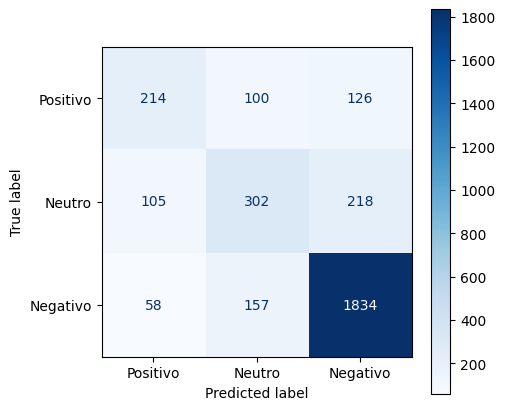

In [3]:
# =======================================================================================================
# MODELO NAIVE BAYES: MultinomialNB
# =======================================================================================================

from sklearn.naive_bayes import MultinomialNB

nbm_clf = MultinomialNB(class_prior=[1/3, 1/3, 1/3], alpha = 0.33)

print("----- Modelo MultinomialNB ", "-" * 50, "\n")

nbm_results, nbm_accuracy = train(nbm_clf, X_train, X_test, y_train, y_test)
nbm_report = evaluation(y_test, nbm_results)

----- Modelo ComplementNB  -------------------------------------------------- 

              precision    recall  f1-score   support

    Positivo       0.53      0.54      0.54       440
      Neutro       0.55      0.47      0.51       625
    Negativo       0.86      0.90      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.65      0.64      0.64      3114
weighted avg       0.75      0.76      0.76      3114



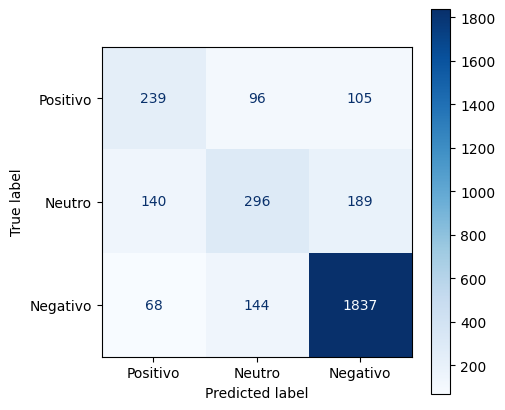

In [4]:
# =======================================================================================================
# MODELO NAIVE BAYES (Alternativa): ComplementNB
# =======================================================================================================

from sklearn.naive_bayes import ComplementNB

nbc_clf = ComplementNB(class_prior=[1/3, 1/3, 1/3], alpha=0.33)

print("----- Modelo ComplementNB ", "-" * 50, "\n")
nbc_results, nbc_accuracy = train(nbc_clf, X_train, X_test, y_train, y_test)
nbc_report = evaluation(y_test, nbc_results)

----- Modelo con Regresión Logística  -------------------------------------------------- 

              precision    recall  f1-score   support

    Positivo       0.47      0.57      0.52       440
      Neutro       0.52      0.65      0.58       625
    Negativo       0.92      0.81      0.86      2049

    accuracy                           0.74      3114
   macro avg       0.64      0.68      0.65      3114
weighted avg       0.78      0.74      0.75      3114



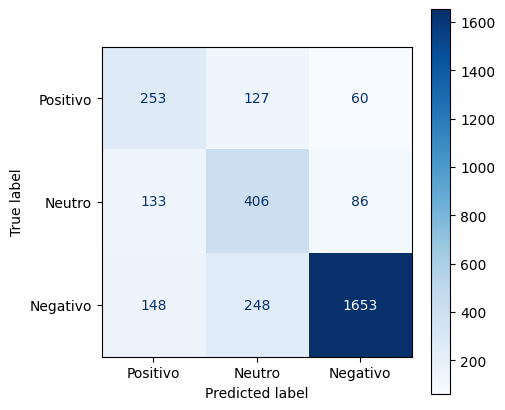

In [ ]:
# =======================================================================================================
# DESBALANCE DE CLASES I. MODELOS BASADOS EN LA REGRESIÓN
# =======================================================================================================

# Logistic regression
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(class_weight="balanced")

print("----- Modelo con Regresión Logística ", "-" * 50, "\n")

log_results, log_accuracy = train(log_clf, X_train, X_test, y_train, y_test)
log_report = evaluation(y_test, log_results)


----- Modelo con Regresión Lineal  -------------------------------------------------- 

              precision    recall  f1-score   support

    Positivo       0.52      0.48      0.50       440
      Neutro       0.56      0.54      0.55       625
    Negativo       0.87      0.89      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.65      0.64      0.64      3114
weighted avg       0.76      0.76      0.76      3114



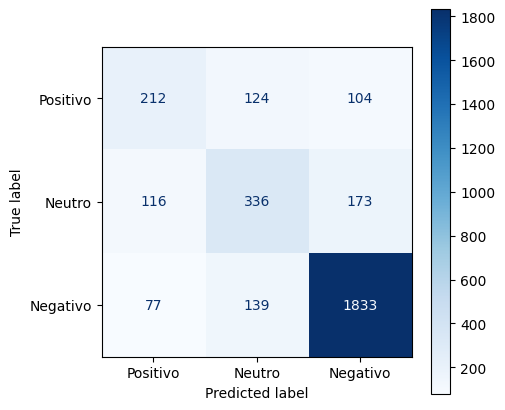

In [ ]:
# Regresión lineal
from sklearn.svm import LinearSVC

lin_clf = LinearSVC(class_weight="balanced")

print("----- Modelo con Regresión Lineal ", "-" * 50, "\n")

lin_results, lin_accuracy = train(lin_clf, X_train, X_test, y_train, y_test)
lin_report = evaluation(y_test, lin_results)


----- Modelo con RandomForest  -------------------------------------------------- 

              precision    recall  f1-score   support

    Positivo       0.83      0.08      0.15       440
      Neutro       0.66      0.37      0.47       625
    Negativo       0.73      0.97      0.83      2049

    accuracy                           0.72      3114
   macro avg       0.74      0.47      0.48      3114
weighted avg       0.73      0.72      0.66      3114



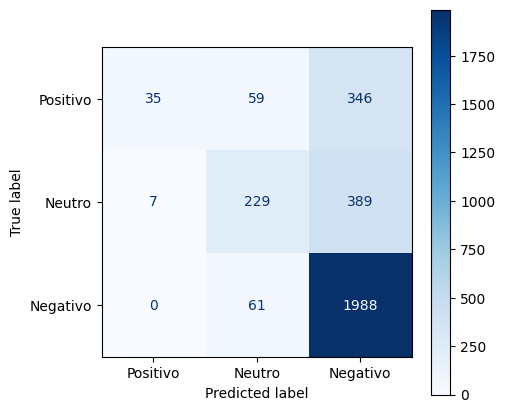

In [8]:
# =======================================================================================================
# DESBALANCE DE CLASES II. MODELOS RandomForest
# =======================================================================================================

# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(class_weight="balanced")

print("----- Modelo con RandomForest ", "-" * 50, "\n")

rf_results, rf_accuracy = train(rf_clf, X_train, X_test, y_train, y_test)
rf_report = evaluation(y_test, rf_results)